In [1]:
%matplotlib ipympl
# from stage 1
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# PCA
from sklearn.decomposition import PCA


D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

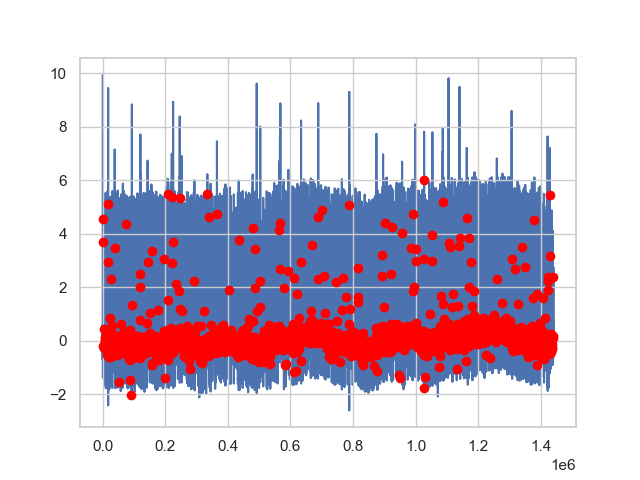

In [2]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

# n = Index1
d1_spikes = np.zeros(len(Index1))
m = 0

for x in Index1:
    # print(d1[x])
    d1_spikes[m] = d1[x]
    m = m + 1
    
plt.figure(0)
plt.plot(d1, zorder=-1)
plt.scatter(Index1, d1_spikes, color='red', zorder=1)  

# Step 1: Spike Detection
- noncausal band pass filter between 300 and 3000 Hz.
- matlab command ‘filtfilt’, which filters the signal in the forward and reverse directions.


In [3]:
from scipy.signal import butter,filtfilt

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], analog=False, btype='band')
        y = filtfilt(b, a, data)
        return y

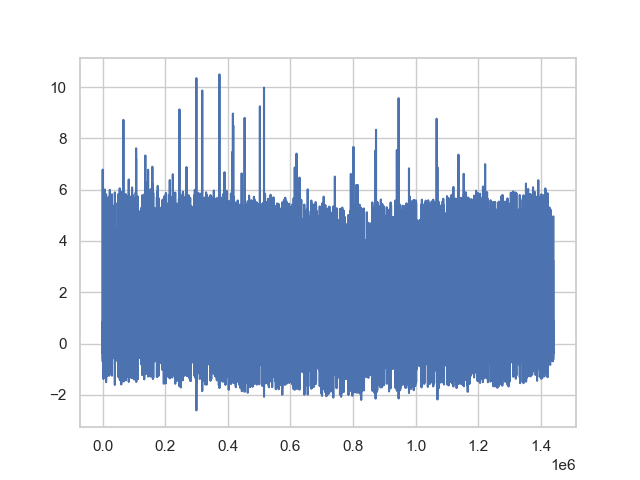

In [4]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']

plt.figure(1)
plt.plot(d2)

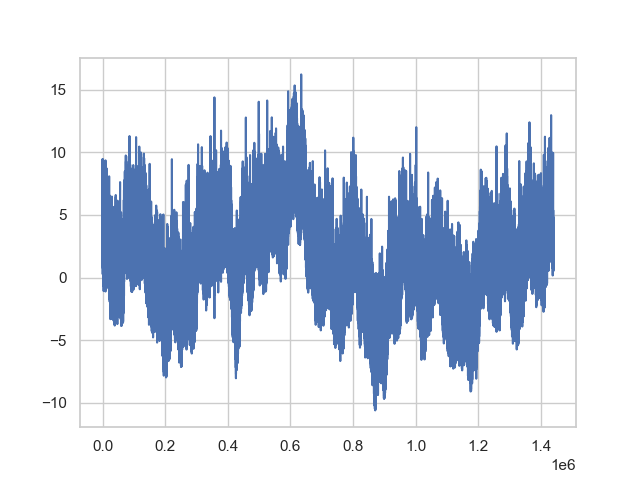

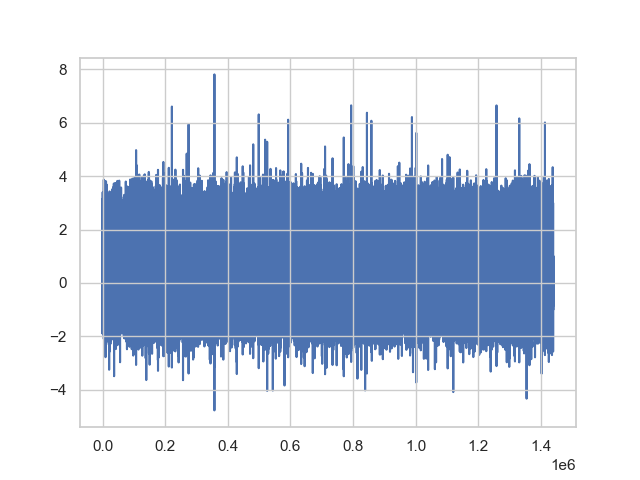

In [5]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

plt.figure(2)
plt.plot(d3)

# Filter requirements.
fs = 25000      # sample rate, Hz
order = 3       # sin wave can be approx represented as quadratic
lowcut = 300
highcut  = 3000

d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)
plt.figure(3)
plt.plot(d3_f, zorder=-1)


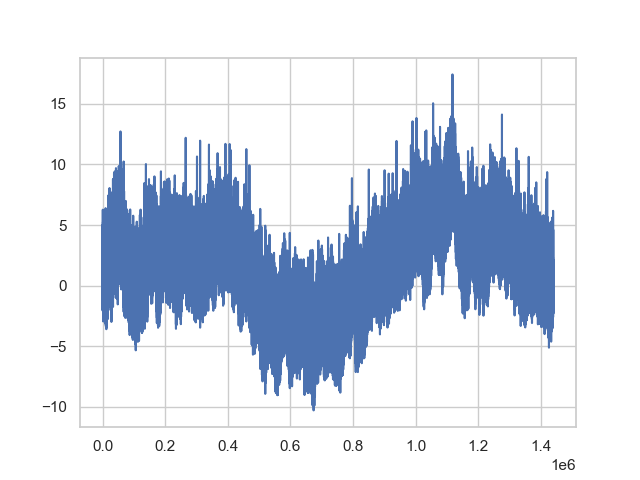

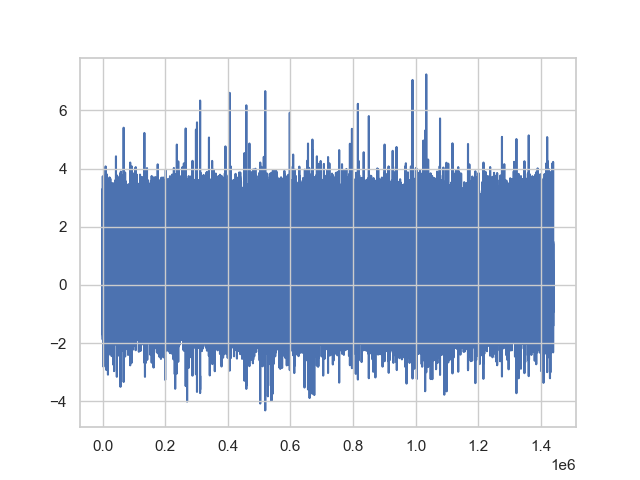

In [6]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

plt.figure(4)
plt.plot(d4)

d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)
plt.figure(5)
plt.plot(d4_f, zorder=-1)

# Step 2:

- spikes are usually detected using an amplitude threshold. The choice of the threshold is a compromise between: i) missing spikes if a high threshold is used (Type II error) and ii) getting false positives due to noise crossing a low threshold (Type I error). 

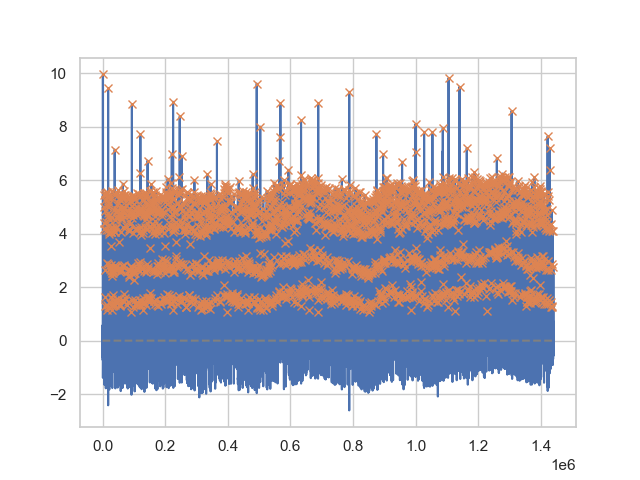

In [7]:
from scipy.signal import find_peaks

# calculate standard deviation of signal using Donoho's estimation
std = (np.median(abs(d1 - np.mean(d1))/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.5, height = ts)

plt.figure(6)
plt.plot(d1)
plt.plot(peaks1, d1[peaks1], "x")
plt.plot(np.zeros_like(d1), "--", color="gray")
plt.show()

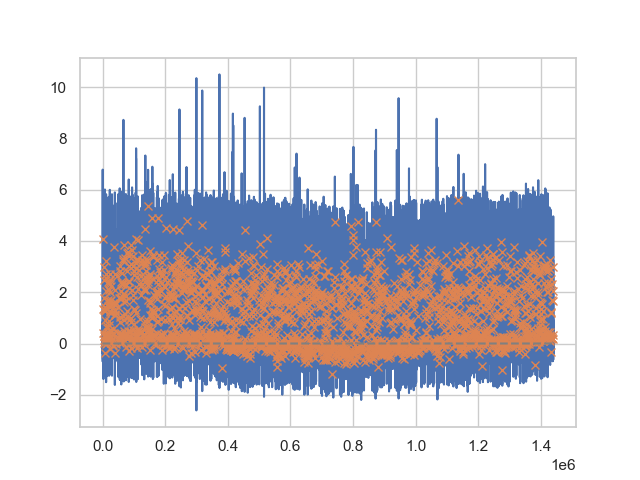

In [8]:
# calculate standard deviation of signal using Donoho's estimation
std2 = (np.median(abs(d2 - np.mean(d2))/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.5, height=ts2)

# plt.figure(4)
# plt.plot(d2)
# plt.plot(peaks2, d2[peaks2], "x")
# plt.plot(np.zeros_like(d2), "--", color="gray")
# plt.show()

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10

plt.figure(7)
plt.plot(d2)
plt.plot(Index2, d2[Index2], "x")
plt.plot(np.zeros_like(d2), "--", color="gray")
plt.show()    

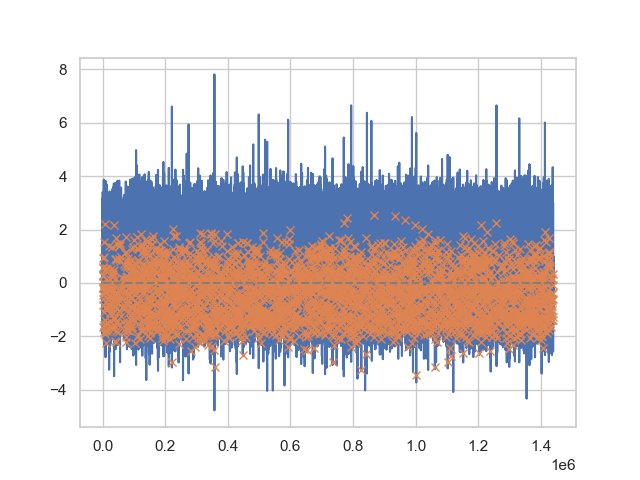

In [9]:
# calculate standard deviation of signal using Donoho's estimation
std3 = (np.median(abs(d3_f - np.mean(d3_f))/0.6745))

# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.5, height=ts3)

# plt.figure(4)
# plt.plot(d3_f)
# plt.plot(peaks3, d3_f[peaks3], "x")
# plt.plot(np.zeros_like(d3_f), "--", color="gray")
# plt.show()

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10

plt.figure(8)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.show()   

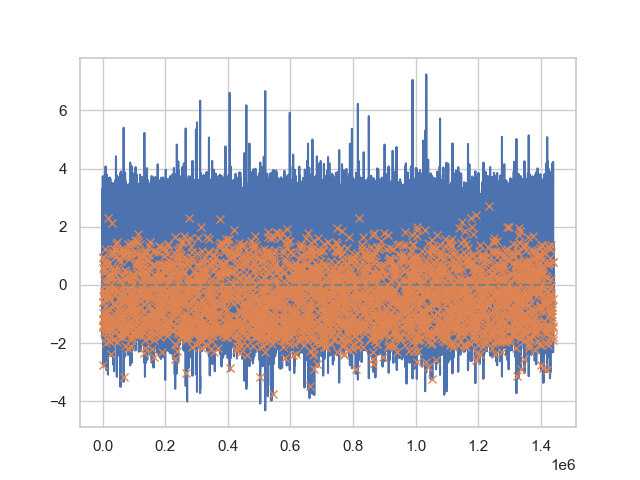

In [10]:
# calculate standard deviation of signal using Donoho's estimation
std4 = (np.median(abs(d4_f - np.mean(d4_f))/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.5, height=ts4)

# plt.figure(4)
# plt.plot(d3_f)
# plt.plot(peaks3, d3_f[peaks3], "x")
# plt.plot(np.zeros_like(d3_f), "--", color="gray")
# plt.show()

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10

plt.figure(9)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.show()   

- the whole spike shape; i.e. about 2 ms of data.
- Some methods for feature extraction, such as wavelets (using a multiresolution decomposition implementation), require that the number of datapoints is a power of 2. 
- alignment of the spike shapes. Spikes can be aligned to their maximum. But due to insufficient sampling the maximum can be at different points of the spike shape. To avoid such misalignments, which could lead to overclustering, the spike shapes can be oversampled using interpolated waveforms, for example, using cubic splines. Then, the interpolated shapes can be aligned and later decimated to the original sampling rate.

In [11]:
# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Define period of each spike
n_2ms = int((25e3) * 3e-3) # int((25e3)/downsample_factor * 2e-3) # 50 for 25kHz 
if n_2ms%2 != 0:
    n_2ms = n_2ms - 1
n = int(n_2ms/2)
spike = np.zeros([n_2ms,len(Index1)])
spike2 = np.zeros([n_2ms,len(Index2)])
spike3 = np.zeros([n_2ms,len(Index3)])
spike4 = np.zeros([n_2ms,len(Index4)])

# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike[:,k] = d1[i:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike2[:,k] = d2[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike3[:,k] = d3_f[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike4[:,k] = d4_f[i:i+n_2ms]
        k = k + 1                        


KeyboardInterrupt: 

# Step 4: Feature Extraction

- extract features of the spike shapes - gives a dimensionality reduction
- By far, the most used method for feature extraction is to take the first 2 or 3 principal components (Glaser and Marks, 1968; Abeles, 1977), usually containing more than 80% of the energy of the signal. However, principal component analysis (PCA) selects the directions of maximum variance of the data, which are not necessarily the directions of best separation. In other words, it may well be that the information for separating the clusters is represented in one (or a combination) of principal components with low eigenvalues, which are usually disregarded.
- More recently it has been proposed to use wavelets for feature extraction 

In [ ]:
# training
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.8)].transpose()
d1_spikes_test = spike[:,int(x*0.8):].transpose()
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()
class1_train = Class1_sorted[0:int(x*0.8)]
class1_test = Class1_sorted[int(x*0.8):]

print(d1_spikes_train.shape)
print(d1_spikes_test.shape)
print(d2_spikes_test.shape)
print(d3_spikes_test.shape)
print(d4_spikes_test.shape)


(1927, 74)
(826, 74)
(2405, 74)
(3431, 74)
(3627, 74)


Total Variance Explained:  0.844032522224397


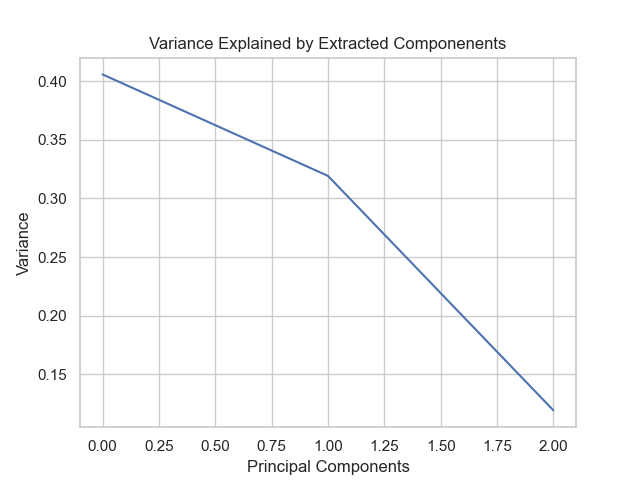

In [ ]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)
# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(10)
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Step 5: Clustering

- group spikes with similar features into clusters, corresponding to the different neurons.
- Bayesian classification 
- Expectation Maximization procedures 

In [ ]:
# Neural network class definition
class NeuralNetwork:
    # Init the network, this gets run whenever we make a new instance of this class
    def __init__(self, input_nodes, hidden_nodes, output_nodes, learning_rate):
        # Set the number of nodes in each input, hidden and output layer
        self.i_nodes = input_nodes
        self.h_nodes = hidden_nodes
        self.o_nodes = output_nodes

        # Weight matrices, with (input -> hidden) and who (hidden -> output)
        self.wih = np.random.normal(0.0, pow(self.h_nodes, -0.5), (self.h_nodes, self.i_nodes))
        self.who = np.random.normal(0.0, pow(self.o_nodes, -0.5), (self.o_nodes, self.h_nodes))

        # Set the learning rate
        self.lr = learning_rate

        # Set the activation function, the logistic sigmoid
        self.activation_function = lambda x: scipy.special.expit(x)
        # self.activation_function = lambda x: np.asarray([max(0, i) for i in x])

    # Train the network using back-propagation of errors
    def train(self, inputs_list, targets_list):
        # Convert inputs into 2D arrays
        inputs_array = np.array(inputs_list, ndmin=2).T
        targets_array = np.array(targets_list, ndmin=2).T

        # Calculate signals into hidden layer
        hidden_inputs = np.dot(self.wih, inputs_array)

        # Calculate signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # Calculate signals into final output layer
        final_inputs = np.dot(self.who, hidden_outputs)

        # Calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)

        # Current error is (target - actual)
        output_errors = targets_array - final_outputs

        # Hidden layer errors are the output errors, split by the weights, recombined at hidden nodes
        hidden_errors = np.dot(self.who.T, output_errors)

        # Update the weights for the links between the hidden and output layers
        self.who += self.lr*np.dot((output_errors*final_outputs*(1.0 - final_outputs)), np.transpose(hidden_outputs))
        # Update the weights for the links between the input and hidden layers
        self.wih += self.lr*np.dot((hidden_errors*hidden_outputs*(1.0 - hidden_outputs)), np.transpose(inputs_array))

    # Query the network
    def query(self, inputs_list):
        # Converts the inputs list into a 2D array
        inputs_array = np.array(inputs_list, ndmin=2).T

        # Calcualte the signals into hidden layer
        hidden_inputs = np.dot(self.wih, inputs_array) 

        # Calculate output from the hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # Calculate signals into final layer
        final_inputs = np.dot(self.who, hidden_outputs)

        # Calculate outputs from the final layer
        final_outputs = self.activation_function(final_inputs)
        # print(final_outputs)
        return final_outputs


In [ ]:
input_nodes = pca_num # n_2ms
hidden_nodes = pca_num * 50 # 50 = 95%
output_nodes = 6 
learning_rate = 0.01 #0.01

n = NeuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate)

In [ ]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)
# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

In [ ]:
# Train the neural network on each training sample
epochs = 100
for e in range(epochs):
#go through all datasets
    i = 0
    for record in train_ext:
        inputs = (np.asfarray(record) / 255.0*0.99) + 0.01
        #create the target output values (all 0.01, except the desired label which is 0.99)
        targets = np.zeros(output_nodes) + 0.01
        # All_values[0] is the target label for this record
        targets[int(class1_train[i])] = 0.99
        # Train the network
        n.train(inputs, targets)
        # print("epoch: ", e, " : ", i, " out of: 60.000")
        i = i + 1
        pass
    print(e)
    pass
print("done")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
done


In [ ]:
# testing

# Scorecard list for how well the network performs, initially empty
scorecard = []

# Loop through all of the records in the test data set
i=0
for record in test_ext:
    # The correct label is the first value
    correct_label = int(class1_test[i])
    print(correct_label, "Correct label")
    # Scale and shift the inputs
    inputs = (np.asfarray(record)/255.0*0.99)+0.01
    # Query the network
    outputs = n.query(inputs)
    # The index of the highest value output corresponds to the label
    label = np.argmax(outputs)
    print(label,"Network label")
    i=i+1
    # Append either a 1 or a 0 to the scorecard list
    if (label == correct_label):
        scorecard.append(1)
    else:
        scorecard.append(0)
        pass
    pass

# Calculate the performance score, the fraction of correct answers
scorecard_array = np.asarray(scorecard)
# Exercise 2
print("Performance = ", (scorecard_array.sum()/scorecard_array.size)*100, '%')

5 Correct label
5 Network label
4 Correct label
4 Network label
3 Correct label
3 Network label
4 Correct label
4 Network label
4 Correct label
4 Network label
2 Correct label
2 Network label
2 Correct label
2 Network label
4 Correct label
4 Network label
1 Correct label
1 Network label
3 Correct label
3 Network label
2 Correct label
2 Network label
4 Correct label
4 Network label
1 Correct label
1 Network label
2 Correct label
2 Network label
5 Correct label
5 Network label
5 Correct label
5 Network label
1 Correct label
1 Network label
1 Correct label
1 Network label
2 Correct label
2 Network label
5 Correct label
5 Network label
4 Correct label
4 Network label
3 Correct label
3 Network label
4 Correct label
4 Network label
1 Correct label
1 Network label
4 Correct label
4 Network label
3 Correct label
3 Network label
3 Correct label
3 Network label
5 Correct label
5 Network label
2 Correct label
2 Network label
4 Correct label
4 Network label
5 Correct label
5 Network label
1 Correc

In [ ]:
# testing for D2

# Scorecard list for how well the network performs, initially empty
scorecard = []
Class2 = np.zeros(len(Index2))

# Loop through all of the records in the test data set
i=0
for record in test_ext2:
    # Scale and shift the inputs
    inputs = (np.asfarray(record)/255.0*0.99)+0.01
    # Query the network
    outputs = n.query(inputs)
    # The index of the highest value output corresponds to the label
    label = np.argmax(outputs)
    Class2[i] = label
    # print(label,"Network label")
    i=i+1
    pass

In [ ]:
from scipy.io import savemat

# mdic = {"d": d2, "Index": Index2_sorted, "Class": Class2 }
# savemat("D2_submit.mat", mdic)

In [ ]:
# testing for D3

# Scorecard list for how well the network performs, initially empty
scorecard = []
Class3 = np.zeros(len(Index3))

# Loop through all of the records in the test data set
i=0
for record in test_ext3:
    # Scale and shift the inputs
    inputs = (np.asfarray(record)/255.0*0.99)+0.01
    # Query the network
    outputs = n.query(inputs)
    # The index of the highest value output corresponds to the label
    label = np.argmax(outputs)
    Class3[i] = label
    # print(label,"Network label")
    i=i+1
    pass

In [ ]:
mdic = {"d": d3, "Index": Index3_sorted, "Class": Class3 }
savemat("D3_submit.mat", mdic)

In [ ]:
# testing for D4

# Scorecard list for how well the network performs, initially empty
scorecard = []
Class4 = np.zeros(len(Index4))

# Loop through all of the records in the test data set
i=0
for record in test_ext4:
    # Scale and shift the inputs
    inputs = (np.asfarray(record)/255.0*0.99)+0.01
    # Query the network
    outputs = n.query(inputs)
    # The index of the highest value output corresponds to the label
    label = np.argmax(outputs)
    Class4[i] = label
    # print(label,"Network label")
    i=i+1
    pass

In [ ]:
mdic = {"d": d4, "Index": Index4_sorted, "Class": Class4 }
savemat("D4_submit.mat", mdic)

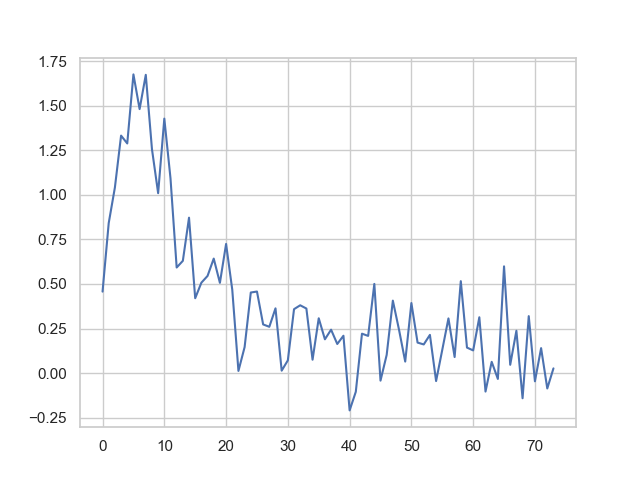

In [ ]:
plt.figure(11)
plt.plot(d1_spikes_test[2])

In [ ]:
plt.figure(7)
plt.plot(d1_spikes_test[5])